In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
file = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Irritation\dataset\train_set_skin_irritation_features_rdkitcdk.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf.drop_duplicates(subset=['SMILES'])
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

(440, 66)
(440, 66)


Index(['Outcome', 'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3', 'Mol'],
      dtype=

In [3]:
moldf

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,1,57,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.084992491992044, -1....",57,CCOCCCOC(O)CC,162.125594436,1.1580000000000001,68.31517003981556,...,3.0,10.0,0.4444444444444444,7.0,0.0,38.69,4.321928094887363,0.857,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002A24BC...
1,1,205,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4178613599092674, 0.13371156740649162, 0.1...",205,CC(C)CC(C)OP(=S)(S)OC(C)C,256.07205854200004,4.016900000000003,98.08278753362214,...,5.0,9.0,0.5,6.0,0.0,99.16,4.700439718141093,4.829000000000001,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002A24BC...
2,0,445,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4106617898955919, 0.4407202217479584, 0.50...",445,CC(C)(C)c1ccc(C#N)cc1,159.104799416,2.855780000000001,73.64869337294873,...,3.0,3.0,0.4285714285714285,1.0,0.0,23.79,4.584962500721156,3.5620000000000007,0.3636363636363636,<rdkit.Chem.rdchem.Mol object at 0x000002A24BC...
3,0,379,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8141666872733075, -0.38901812751285475, -0...",379,C=Cn1ccnc1,94.053098192,0.9835999999999999,42.11046420466207,...,2.0,2.0,0.5,1.0,0.0,17.82,3.807354922057604,0.7189999999999999,0.0,<rdkit.Chem.rdchem.Mol object at 0x000002A24BC...
4,1,110,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6957883439207186, 0.02886774372723733, 0.0...",110,CO[Si](OC)(OC)OC,152.05048539400002,0.007599999999999829,56.162559650057005,...,0.0,5.0,0.5,4.0,0.0,36.92,4.0,0.208,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002A24BC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,0,307,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.932053295431659, 1.0888498501770312, 1.0071...",307,CC1=NN(c2ccccc2)C(=O)/C1=N/Nc1ccc(-c2ccc(N/N=C...,622.1399273680001,7.041600000000004,262.52136273165746,...,0.0,2.0,0.48,7.0,2.0,114.12,6.614709844115208,8.981999999999998,0.0625,<rdkit.Chem.rdchem.Mol object at 0x000002A24D0...
436,0,342,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.1499050992731923, 1.5597216913092669, 1.636...",342,Cc1ccc2[nH]c3cc4c(=O)c5cc(C)ccc5[nH]c4cc3c(=O)...,340.12117775199994,4.292840000000003,147.65028563721154,...,0.0,0.0,0.4615384615384615,0.0,1.0,65.72,5.906890595608519,7.008,0.0909090909090909,<rdkit.Chem.rdchem.Mol object at 0x000002A24D0...
437,0,463,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.018564746005525636, 0.6431375900855004, 0.3...",463,CCCCCC1C(=O)CCC1CC(=O)OC,226.156894564,2.725100000000001,97.54931467665402,...,5.0,5.0,0.5,7.0,0.0,43.370000000000005,5.0,2.655,0.8461538461538461,<rdkit.Chem.rdchem.Mol object at 0x000002A24D0...
438,1,218,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.15969601443774015, 0.9458664461470997, 1.0...",218,C=CCOC(=O)C1C(C)CCCC1(C)C,210.161979944,3.1780000000000017,92.698189544426,...,3.0,6.0,0.5,4.0,0.0,26.3,4.906890595608519,4.391,0.7692307692307693,<rdkit.Chem.rdchem.Mol object at 0x000002A24D0...


In [4]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

moldf.head(1)

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,1,57,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.084992491992044, -1....",57,CCOCCCOC(O)CC,162.125594436,1.1580000000000001,68.31517003981556,...,3.0,10.0,0.4444444444444444,7.0,0.0,38.69,4.321928094887363,0.857,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002A24BC...


In [5]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf.head(100)

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
439,0,311,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.1169985226416057, 0.8038501231707679, 0.869...",311,COc1ccc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=...,688.16038804,6.6688000000000045,285.6621839412296,...,4.0,5.0,0.4827586206896552,15.0,3.0,159.57999999999998,6.672425341971496,11.06,0.1176470588235294,<rdkit.Chem.rdchem.Mol object at 0x000002A24D0...
169,0,471,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8209384939334945, -1.1381678094099636, -1....",471,CCOC(=O)CC#N,113.047678464,0.46318,47.866666496435336,...,3.0,7.0,0.5,3.0,0.0,50.09,3.807354922057604,-0.0239999999999999,0.6,<rdkit.Chem.rdchem.Mol object at 0x000002A24BE...
350,0,483,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.08124978430701464, 0.7906430880924455, 0.8...",483,CCC(CC)CC1(C(=O)O)CCCCC1,212.177630008,3.847800000000002,93.0684810992994,...,5.0,5.0,0.4285714285714285,5.0,0.0,37.3,4.906890595608519,4.818,0.9230769230769232,<rdkit.Chem.rdchem.Mol object at 0x000002A24CF...
171,0,389,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2647432853628807, 1.155408661307298, 0.779...",389,O=Cc1cccc2c1OC(F)(F)O2,186.012850428,1.8205999999999996,71.87513955967094,...,0.0,2.0,0.5,1.0,0.0,35.53,4.807354922057604,1.915,0.125,<rdkit.Chem.rdchem.Mol object at 0x000002A24BE...
172,0,337,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.0074553277658636, 1.6379482248483923, 1.716...",337,Cc1cc(C)c(Nc2ccc(Nc3c(C)cc(C)cc3C)c3c2C(=O)c2c...,474.23072819999993,7.799720000000007,211.9391600666363,...,0.0,0.0,0.4666666666666667,4.0,1.0,58.2,6.321928094887363,7.31,0.1875,<rdkit.Chem.rdchem.Mol object at 0x000002A24BE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0,393,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.0849924919920417, -1...",393,C=CC(=O)NCOCCCC,157.11027872,1.0628,67.42917230958022,...,4.0,10.0,0.4444444444444444,7.0,0.0,38.33,4.321928094887363,1.2990000000000002,0.625,<rdkit.Chem.rdchem.Mol object at 0x000002A24CF...
213,0,436,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.16107563113077308, 1.760296803470762, 1.371...",436,CC1C2CC(CC2C2CCC(O)CC2)C1(C)C,236.21401551600002,3.855800000000003,105.99012303538699,...,0.0,0.0,0.4444444444444444,1.0,1.0,20.23,5.247927513443585,6.01,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002A24BE...
214,0,321,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.31808477227625076, 0.7037688883054578, 0.76...",321,C=CCOC(=O)C(C)(C)OC(=O)c1cc(N)ccc1Cl,297.076785672,2.5868,121.85462858548127,...,3.0,9.0,0.4545454545454545,7.0,0.0,78.62,5.321928094887363,2.717,0.2857142857142857,<rdkit.Chem.rdchem.Mol object at 0x000002A24BE...
327,0,417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2689332319795547, 0.7723099185293252, 0.455...",417,CCCCCC1=C(OC(C)=O)CCC1CC(=O)OC,268.167459248,3.357000000000002,114.70314110276986,...,5.0,5.0,0.5,9.0,0.0,52.60000000000001,5.247927513443585,2.8040000000000003,0.7333333333333333,<rdkit.Chem.rdchem.Mol object at 0x000002A24CF...


In [6]:
x_data = moldf.drop(columns=['Outcome', 'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP','Mol'])
print(x_data)

              LabuteASA                TPSA                 AMW  \
439   285.6621839412296  159.57999999999998   689.5560000000003   
169  47.866666496435336               50.09             113.116   
350    93.0684810992994                37.3  212.33299999999994   
171   71.87513955967094               35.53  186.11299999999994   
172   211.9391600666363  58.199999999999996   474.6040000000003   
..                  ...                 ...                 ...   
190  105.87505801565905               20.23  234.38299999999995   
188  203.91558285601675   73.84000000000002   496.7580000000005   
187  61.885340423554176                 0.0             132.206   
183  123.52032313975356               36.92  288.42800000000005   
219   95.31267636830194                 0.0             264.366   

    NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
439             10              4                13      4     10   
169              3              0                 2      

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y_data = le.transform( moldf['Outcome'] )

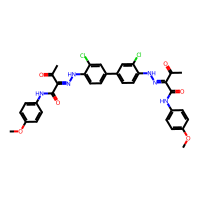

COc1ccc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=O)C(=O)Nc4ccc(OC)cc4)c(Cl)c3)cc2Cl)C(C)=O)cc1


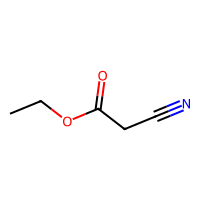

CCOC(=O)CC#N


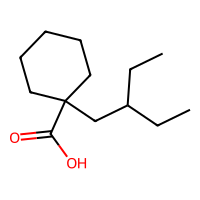

CCC(CC)CC1(C(=O)O)CCCCC1


In [8]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(df, num_mols):
    for _, row in df.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 3)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [212 228]
Total number of cpds             :  440


C:\Users\User\AppData\Local\Temp\ipykernel_19664\776689932.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  S = S.replace(cls,i)


{'0': 0, '1': 1}

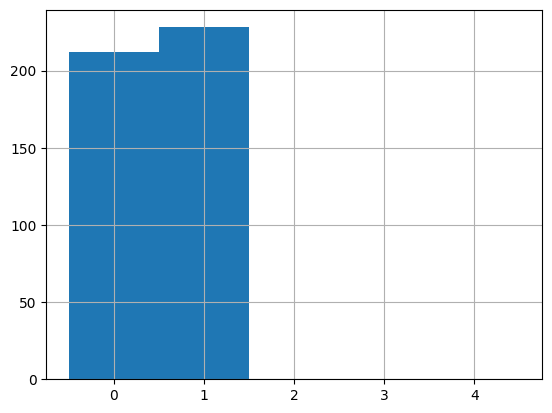

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( moldf['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = moldf['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#GRAPH MATRIX
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [11]:
x = x_data
y = y_data

x

,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
439,285.6621839412296,159.57999999999998,689.5560000000003,10,4,13,4,10,2,14,...,4.0,4.0,5.0,0.4827586206896552,15.0,3.0,159.57999999999998,6.672425341971496,11.06,0.1176470588235294
169,47.866666496435336,50.09,113.116,3,0,2,0,3,0,3,...,0.0,3.0,7.0,0.5,3.0,0.0,50.09,3.807354922057604,-0.0239999999999999,0.6
350,93.0684810992994,37.3,212.33299999999994,1,1,5,1,1,0,2,...,1.0,5.0,5.0,0.4285714285714285,5.0,0.0,37.3,4.906890595608519,4.818,0.9230769230769232
171,71.87513955967094,35.53,186.11299999999994,3,0,1,0,3,0,5,...,0.0,0.0,2.0,0.5,1.0,0.0,35.53,4.807354922057604,1.915,0.125
172,211.9391600666363,58.199999999999996,474.6040000000003,4,2,4,2,4,0,4,...,2.0,0.0,0.0,0.4666666666666667,4.0,1.0,58.2,6.321928094887363,7.31,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,105.87505801565905,20.23,234.38299999999995,1,1,4,1,1,0,1,...,1.0,4.0,4.0,0.5,4.0,1.0,20.23,5.08746284125034,6.177,0.625
188,203.91558285601675,73.84000000000002,496.7580000000005,8,0,28,0,8,0,9,...,0.0,4.0,17.0,0.5,28.0,1.0,73.84000000000002,6.0,4.848000000000001,1.0
187,61.885340423554176,0.0,132.206,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.4,0.0,0.0,0.0,4.459431618637298,3.484,0.4
183,123.52032313975356,36.92,288.42800000000005,4,0,8,0,4,0,4,...,0.0,4.0,5.0,0.5,8.0,1.0,36.92,5.321928094887363,5.356999999999999,1.0


In [12]:
# Random Forest 
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Param grid
paramgrid = {
    "n_estimators": [300],
    "max_features": [10,20],   # ≈ sqrt(56), 1/4, 1/3
    "max_depth": [7,15],
    "min_samples_leaf": [4, 6],
    "min_samples_split": [2,4]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk RandomForest
model_rf_physicochemical = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit model
model_rf_physicochemical.fit(x, y)

# Best model
best_model_rf_physicochemical = model_rf_physicochemical.best_estimator_

print("Best parameters found: ", model_rf_physicochemical.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found:  {'max_depth': 15, 'max_features': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


In [13]:
#Random Forest 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_rf_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_physicochemical.predict(X_test)
    y_proba = best_model_rf_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[29 14]
 [10 35]]
Confusion Matrix for Fold 2:
[[29 14]
 [12 33]]
Confusion Matrix for Fold 3:
[[26 16]
 [12 34]]
Confusion Matrix for Fold 4:
[[30 12]
 [ 8 38]]
Confusion Matrix for Fold 5:
[[29 13]
 [17 29]]
Overall CV Accuracy: 0.7090909090909092
Overall CV AUC: 0.7782841414287319
Overall CV Precision: 0.7093779128672747
Overall CV Recall (Sensitivity): 0.7413526570048309
Overall CV F1 Score: 0.724232612900513
Overall CV Specificity: 0.6745293466223699
Overall CV PPV (Positive Predictive Value): 0.7093779128672747
Overall CV NPV (Negative Predictive Value): 0.7110051619790974
Overall CV CCR (Correct Classification Rate): 0.7079410018136004


In [14]:
# SVM 
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC

# Param grid
paramgrid = {
    "C": [0.1, 1, 10, 100, 220, 440,],
    "kernel": ["rbf"],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"]
}


# Cross-validator (5 splits)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk SVM
model_svm_physicochemical = GridSearchCV(
    estimator=SVC(class_weight="balanced", probability=True),
    param_grid=paramgrid,   
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit model
model_svm_physicochemical.fit(x, y)

# Best model
best_model_svm_physicochemical = model_svm_physicochemical.best_estimator_

print("Best parameters found: ", model_svm_physicochemical.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'C': 440, 'gamma': 'scale', 'kernel': 'rbf'}


In [15]:
#SVM 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_svm_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_physicochemical.predict(X_test)
    y_proba = best_model_svm_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[26 17]
 [10 35]]
Confusion Matrix for Fold 2:
[[27 16]
 [ 9 36]]
Confusion Matrix for Fold 3:
[[25 17]
 [15 31]]
Confusion Matrix for Fold 4:
[[21 21]
 [ 7 39]]
Confusion Matrix for Fold 5:
[[29 13]
 [10 36]]
Overall CV Accuracy: 0.6931818181818181
Overall CV AUC: 0.7241206445503716
Overall CV Precision: 0.6791823652537938
Overall CV Recall (Sensitivity): 0.7764251207729469
Overall CV F1 Score: 0.7234471574608363
Overall CV Specificity: 0.603654485049834
Overall CV PPV (Positive Predictive Value): 0.6791823652537938
Overall CV NPV (Negative Predictive Value): 0.7181623931623932
Overall CV CCR (Correct Classification Rate): 0.6900398029113904


In [16]:
#XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.impute import SimpleImputer
import pandas as pd

# Pastikan x numeric
x = x.apply(pd.to_numeric, errors="coerce")

# Imputer NaN
imputer = SimpleImputer(strategy="median")
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

y = pd.to_numeric(y, errors="coerce").astype(int)

# Parameter
paramgrid = {
    "max_depth": [2,5],
    "n_estimators": [50,100,150,200],
    "learning_rate": [0.05, 0.1,0.2]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk XGBClassifier
model_xgb_physicochemical = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit model
model_xgb_physicochemical.fit(x, y)

# Best model
best_model_xgb_physicochemical = model_xgb_physicochemical.best_estimator_

print("Best parameters found: ", model_xgb_physicochemical.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}


In [17]:
#XGB Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_xgb_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_physicochemical.predict(X_test)
    y_proba = best_model_xgb_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[30 13]
 [10 35]]
Confusion Matrix for Fold 2:
[[28 15]
 [ 8 37]]
Confusion Matrix for Fold 3:
[[24 18]
 [10 36]]
Confusion Matrix for Fold 4:
[[28 14]
 [ 9 37]]
Confusion Matrix for Fold 5:
[[25 17]
 [17 29]]
Overall CV Accuracy: 0.7022727272727274
Overall CV AUC: 0.779617378464699
Overall CV Precision: 0.6926593547117844
Overall CV Recall (Sensitivity): 0.7634782608695653
Overall CV F1 Score: 0.725779230105599
Overall CV Specificity: 0.6364341085271319
Overall CV PPV (Positive Predictive Value): 0.6926593547117844
Overall CV NPV (Negative Predictive Value): 0.7171309965427614
Overall CV CCR (Correct Classification Rate): 0.6999561846983485


In [59]:
# ===============================
# Neural Network - Physicochemical
# ===============================

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#Parameter
paramgrid = {
    "mlp__hidden_layer_sizes": [(256,128), (512,256,128), (1024,512,256,128)], 
    "mlp__activation": ["relu"],
    "mlp__solver": ["adam"],
    "mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate_init": [0.001]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# Pipeline, scaling 
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=800,
        random_state=42,
        early_stopping=True
    ))
])

# GridSearchCV
model_nn_physicochemical = GridSearchCV(
    estimator=pipeline,
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=2,
    n_jobs=-1
)

# Fit model
model_nn_physicochemical.fit(x, y)
best_model_nn_physicochemical = model_nn_physicochemical.best_estimator_

print("Best parameters found:")
print(model_nn_physicochemical.best_params_)
print("Best CV Kappa:", model_nn_physicochemical.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:
{'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (512, 256, 128), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}
Best CV Kappa: 0.4413244356472076


In [60]:
#NN Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_nn_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_nn_physicochemical.predict(X_test)
    y_proba = best_model_nn_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[28 15]
 [14 31]]
Confusion Matrix for Fold 2:
[[30 13]
 [12 33]]
Confusion Matrix for Fold 3:
[[25 17]
 [11 35]]
Confusion Matrix for Fold 4:
[[27 15]
 [11 35]]
Confusion Matrix for Fold 5:
[[25 17]
 [13 33]]
Overall CV Accuracy: 0.6863636363636363
Overall CV AUC: 0.7618440945640137
Overall CV Precision: 0.6848762541806022
Overall CV Recall (Sensitivity): 0.7322705314009662
Overall CV F1 Score: 0.7075091575091574
Overall CV Specificity: 0.6364341085271319
Overall CV PPV (Positive Predictive Value): 0.6848762541806022
Overall CV NPV (Negative Predictive Value): 0.6887635756056808
Overall CV CCR (Correct Classification Rate): 0.684352319964049


In [49]:
import pandas as pd
import numpy as np

print("Dtype per kolom:")
print(x.dtypes.value_counts())

non_numeric = x.select_dtypes(exclude=[np.number])
print("\nJumlah kolom non-numeric:", non_numeric.shape[1])

if non_numeric.shape[1] > 0:
    print("Contoh kolom non-numeric:")
    print(non_numeric.columns[:5])


Dtype per kolom:
float64    56
Name: count, dtype: int64

Jumlah kolom non-numeric: 0


In [50]:
import numpy as np

corr = np.corrcoef(x.astype(float).values, rowvar=False)

upper = np.triu(np.abs(corr), k=1)
high_corr_pairs = np.sum(upper > 0.9)

print("Jumlah pasangan fitur dengan |corr| > 0.9:", high_corr_pairs)


Jumlah pasangan fitur dengan |corr| > 0.9: 87


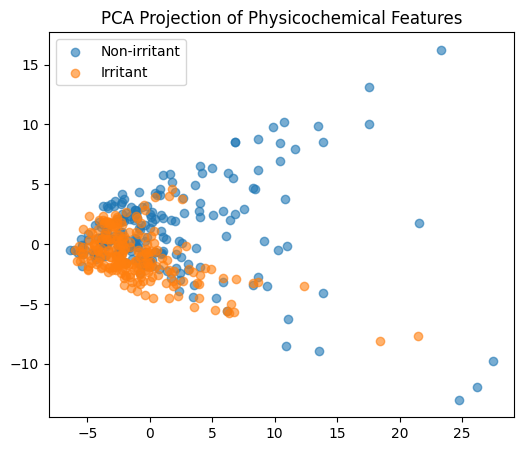

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Xs = StandardScaler().fit_transform(x.astype(float))
pca = PCA(n_components=2)
Xp = pca.fit_transform(Xs)

plt.figure(figsize=(6,5))
plt.scatter(Xp[y==0,0], Xp[y==0,1], alpha=0.6, label="Non-irritant")
plt.scatter(Xp[y==1,0], Xp[y==1,1], alpha=0.6, label="Irritant")
plt.legend()
plt.title("PCA Projection of Physicochemical Features")
plt.show()


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    x.astype(float),
    y,
    scoring="roc_auc",
    cv=cv
)

print("LogReg AUC per fold:", scores)
print("Mean AUC:", scores.mean())


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

LogReg AUC per fold: [0.78914729 0.77105943 0.7199793  0.82039337 0.78416149]
Mean AUC: 0.7769481759673872


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid: 2 × 2 × 2 = 8 kombinasi
paramgrid = {
     "max_depth": [3,6,9],
     "n_estimators": [300,500],
     "learning_rate": [0.05]
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk LGBMClassifier
model_lgbm_physicochemical = GridSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit model
model_lgbm_physicochemical.fit(x, y)

# Best model
best_model_lgbm_physicochemical = model_lgbm_physicochemical.best_estimator_

print("Best parameters found: ", model_lgbm_physicochemical.best_params_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}


In [33]:
#LGBM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_lgbm_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_lgbm_physicochemical.predict(X_test)
    y_proba = best_model_lgbm_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[32 11]
 [ 8 37]]
Confusion Matrix for Fold 2:
[[31 12]
 [ 9 36]]
Confusion Matrix for Fold 3:
[[25 17]
 [10 36]]
Confusion Matrix for Fold 4:
[[28 14]
 [ 8 38]]
Confusion Matrix for Fold 5:
[[26 16]
 [16 30]]
Overall CV Accuracy: 0.725
Overall CV AUC: 0.7801338533391112
Overall CV Precision: 0.716604352032982
Overall CV Recall (Sensitivity): 0.7766183574879226
Overall CV F1 Score: 0.7449698635032235
Overall CV Specificity: 0.6692137320044297
Overall CV PPV (Positive Predictive Value): 0.716604352032982
Overall CV NPV (Negative Predictive Value): 0.7372222222222222
Overall CV CCR (Correct Classification Rate): 0.7229160447461762


In [61]:
#Save model
import joblib
joblib.dump(best_model_rf_physicochemical, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/physical chemical properties (model)/Model_Skin Irr_toxicity_RF_rdkit_cdk.pkl',compress=9)
joblib.dump(best_model_svm_physicochemical, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/physical chemical properties (model)/Model_Skin Irr_toxicity_SVM_rdkit_cdk.pkl',compress=9)
joblib.dump(best_model_xgb_physicochemical, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/physical chemical properties (model)/Model_Skin Irr_toxicity_XGB_rdkit_cdk.pkl',compress=9)
joblib.dump(best_model_nn_physicochemical, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/physical chemical properties (model)/Model_Skin Irr_toxicity_NN_rdkit_cdk.pkl',compress=9)
joblib.dump(best_model_lgbm_physicochemical, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/physical chemical properties (model)/Model_Skin Irr_toxicity_LGBM_rdkit_cdk.pkl',compress=9)


['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/physical chemical properties (model)/Model_Skin Irr_toxicity_LGBM_rdkit_cdk.pkl']